# MA #2 MONEYBALL OLS REGRESSION PROJECT
School of Professional Studies | Northwestern University

200 Points Total

---

This assignment builds directly on MA #1. You will continue developing your regression model, exploring increasingly complex specifications while keeping the principle of *parsimony* in mind: find the best-fitting model with the least unnecessary complexity - one you can clearly explain and defend.  

---

**DELIVERABLES**
- **Write-up (PDF or HTML)**. Five clearly labeled sections with enough detail for me to follow your logic and for a third party to replicate your work. Jupyter Notebooks exported as HTML are accepted. 
- **R Code (Python) file**. A single file containing all code used in your analysis. I must be able to run it and reproduce your output exactly.
- **Scored predictions (CSV)**. Scored records from `moneyball_test.csv`, with exactly two columns: **INDEX** and **P_TARGET_WINS**. Name the file yourname_410_hw02.csv.

---

Four models with increasing complexity: 
- **Model 1** - MA #1 Model 2 (EDA-Informed) re-estimated as baseline
- **Model 2** - Truncated variables
- **Model 3** - Log(TARGET_WINS) response transformation
- **Model 4** - Best candidate synthesis model

---
## Section 0: Setup & Data Cleaning Pipeline

Carried over from MA #1, re-derived here from scratch for full reproducibility. Every frozen constant (outlier thresholds, imputation medians) is computed from `train.csv` only and stored explicitely so the identical values can be applied to `test.csv` is Section 5. 

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

In [5]:
train_raw = pd.read_csv('moneyball_train.csv', index_col=0)
test_raw = pd.read_csv('moneyball_test.csv', index_col=0)

print(f"Train shape: {train_raw.shape}")
print(f"Test shape: {test_raw.shape}")

Train shape: (2276, 17)
Test shape: (259, 16)


### 0.1 Outlier Detection & Repair

In [7]:
# Four pitching/fielding columns showed a scaling-normalization corruption issue in MA #1
# Used Tukey upper bound (Q3 + 1.5*IQR) on each of the four columns; a row is flagged as CORRUPTED if it breaches the bound in >=2 of the 4 columns simultaneously
# All zero/implausibly low values in TEAM_BATTING_HR, TEAM_PITCHING_HR, TEAM_BATTING_SO were also found to cluster within those same 191 corrupted rows
# All 7 columns are nulled out for corrupted rows

DETECTION_COLS = ['TEAM_PITCHING_H', 'TEAM_PITCHING_BB', 'TEAM_PITCHING_SO', 'TEAM_FIELDING_E']
REPAIR_COLS = DETECTION_COLS + ['TEAM_BATTING_HR', 'TEAM_PITCHING_HR', 'TEAM_BATTING_SO']

# Compute and store frozen upper bounds from train only
frozen_upper_bounds = {}
for c in DETECTION_COLS: 
    q1, q3 = train_raw[c].quantile([0.25, 0.75])
    frozen_upper_bounds[c] = round(q3 + 1.5 * (q3 - q1), 2)

print("Frozen outlier upper bounds (from trian):")
for c, v in frozen_upper_bounds.items():
    print(f" {c}: {v}")

def flag_corrupted(df, bounds, min_flags=2):
    flags = pd.DataFrame({c: df[c] > bounds[c] for c in bounds}, index=df.index)
    return flags.sum(axis=1) >= min_flags

corrupted_train = flag_corrupted(train_raw, frozen_upper_bounds)
print(f"\nCorrupted rows in train: {corrupted_train.sum()} of {len(train_raw)}")

train_clean = train_raw.copy()
train_clean.loc[corrupted_train, REPAIR_COLS] = np.nan

Frozen outlier upper bounds (from trian):
 TEAM_PITCHING_H: 2077.75
 TEAM_PITCHING_BB: 813.5
 TEAM_PITCHING_SO: 1497.5
 TEAM_FIELDING_E: 432.62

Corrupted rows in train: 191 of 2276


### 0.2 Median Imputation

In [9]:
# All medians computed from train_clean only and stored frozen for reuse on test
IMPUTE_COLS = REPAIR_COLS + ['TEAM_BASERUN_CS', 'TEAM_FIELDING_DP',
                             'TEAM_BASERUN_SB', 'TEAM_BATTING_HBP']

frozen_medians = train_clean[IMPUTE_COLS].median()
print("Frozen medians (from train_clean):")
print(frozen_medians)

train_imputed = train_clean.copy()
for c in IMPUTE_COLS:
    train_imputed[c] = train_imputed[c].fillna(frozen_medians[c])

print(f"\nMissing values remaining in train_imputed: {train_imputed.isna().sum().sum()}")

Frozen medians (from train_clean):
TEAM_PITCHING_H     1501.0
TEAM_PITCHING_BB     539.0
TEAM_PITCHING_SO     814.0
TEAM_FIELDING_E      153.0
TEAM_BATTING_HR      109.0
TEAM_PITCHING_HR     112.0
TEAM_BATTING_SO      786.0
TEAM_BASERUN_CS       49.0
TEAM_FIELDING_DP     149.0
TEAM_BASERUN_SB      101.0
TEAM_BATTING_HBP      58.0
dtype: float64

Missing values remaining in train_imputed: 0


### 0.3 Feature Engineering

In [11]:
# All features derived - no parameters estimated from data so these can be applied identically to test.csv

# Missing-indicator flag for HBP (92% missing - era signal, not noise)
train_imputed['TEAM_BATTING_HBP_WAS_MISSING'] = train_clean['TEAM_BATTING_HBP'].isna().astype(int)

# Total bases (standard slugging weights, avoids double-counting singles)
train_imputed['TEAM_BATTING_TB'] = (train_imputed['TEAM_BATTING_H']
                                    + train_imputed['TEAM_BATTING_2B']
                                    + 2 * train_imputed['TEAM_BATTING_3B']
                                    + 3 * train_imputed['TEAM_BATTING_HR'])

# Offense proxy: total bases + walks
train_imputed['OFFENSE_PROXY'] = train_imputed['TEAM_BATTING_TB'] + train_imputed['TEAM_BATTING_BB']

# Log transforms for right-skewed columns (log outperformed sqrt empirically in MA #1)
train_imputed['TEAM_FIELDING_E_LOG'] = np.log(train_imputed['TEAM_FIELDING_E'])
train_imputed['TEAM_PITCHING_H_LOG'] = np.log(train_imputed['TEAM_PITCHING_H'])

# Era bin: dead-ball vs. live-ball era (valley in TEAM_BATTING_HR distribution at ~84)
train_imputed['LOW_HR_ERA'] = (train_imputed['TEAM_BATTING_HR'] < 84).astype(int)

print("Engineered features added:")
new_cols = ['TEAM_BATTING_HBP_WAS_MISSING', 'TEAM_BATTING_TB', 'OFFENSE_PROXY', 
            'TEAM_FIELDING_E_LOG', 'TEAM_PITCHING_H_LOG', 'LOW_HR_ERA']
print(train_imputed[new_cols].describe().round(2))

Engineered features added:
       TEAM_BATTING_HBP_WAS_MISSING  TEAM_BATTING_TB  OFFENSE_PROXY  \
count                       2276.00          2276.00        2276.00   
mean                           0.92          2138.27        2639.83   
std                            0.28           264.58         306.63   
min                            0.00          1353.00        1353.00   
25%                            1.00          1959.75        2443.00   
50%                            1.00          2142.00        2646.50   
75%                            1.00          2301.00        2839.00   
max                            1.00          3509.00        3787.00   

       TEAM_FIELDING_E_LOG  TEAM_PITCHING_H_LOG  LOW_HR_ERA  
count              2276.00              2276.00     2276.00  
mean                  5.14                 7.33        0.34  
std                   0.44                 0.11        0.47  
min                   4.17                 7.04        0.00  
25%                   4

---
## Section 1: Modeling

### 1.1 Model 1 - EDA-Informed Baseline (MA #1 Model 2, Re-estimated)

Re-estimation of MA #1's selected model on the same cleaned training data. Serves as the baseline for all subsequent comparisons. Eight predictors, all statistically significant or retained with documented justification. 

Predictors: 
- `OFFENSE_PROXY` - total bases + walks; replaces raw batting components to avoid multicollinearity
- `LOW_HR_ERA` - binary era flag (dead-ball vs. live-ball); replaces both `TEAM_BATTING_HR` and `TEAM_PITCHING_HR` whose r = 0.969 collinearity caused severe VIF inflation (283/273) in the kitchen-sink model
- `TEAM_FIELDING_E_LOG` - log-transformed errors allowed; skew reduced from 2.50 to 1.19
- `TEAM_BATTING_HBP_WAS_MISSING` - indicator for records where HBP was never tracked
- `TEAM_BATTING_SO` - strikeouts by batters (negative effect on wins)
- `TEAM_BASERUN_SB` - stolen bases (positive)
- `TEAM_PITCHING_SO` - strikeouts by pitchers (retained despite marginal significance; documented)
- `TEAM_FIELDING_DP` - double plays (negative; opportunity-dependent stat)

In [13]:
MODEL_1_COLS = ['OFFENSE_PROXY', 'LOW_HR_ERA', 'TEAM_FIELDING_E_LOG', 
                'TEAM_BATTING_HBP_WAS_MISSING', 'TEAM_BATTING_SO', 
                'TEAM_BASERUN_SB', 'TEAM_FIELDING_DP']

# TEAM_PITCHING_SO dropped: insignificant (p=0.594) and VIF=11.69 flagged collinearity with TEAM_BATTING_SO (VIF=14.95)
# Both tracking the same era-level strikeout signal
# Assignment guidance: remove predictors with VIG > 10, especially when also insignificant

y = train_imputed['TARGET_WINS']
X1 = sm.add_constant(train_imputed[MODEL_1_COLS])
model_1 = sm.OLS(y, X1).fit()
print(model_1.summary())

                            OLS Regression Results                            
Dep. Variable:            TARGET_WINS   R-squared:                       0.310
Model:                            OLS   Adj. R-squared:                  0.308
Method:                 Least Squares   F-statistic:                     145.7
Date:                Mon, 13 Jul 2026   Prob (F-statistic):          9.08e-178
Time:                        18:48:30   Log-Likelihood:                -9081.3
No. Observations:                2276   AIC:                         1.818e+04
Df Residuals:                    2268   BIC:                         1.822e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const           

### 1.2 Model 1 - VIF Check

In [15]:
Xv1 = train_imputed[MODEL_1_COLS].assign(const=1)
vif1 = pd.Series(
    [variance_inflation_factor(Xv1.values, i) for i in range(len(MODEL_1_COLS))],
    index=MODEL_1_COLS
).sort_values(ascending=False).round(2)
print("Model 1 VIF:")
print(vif1)

Model 1 VIF:
TEAM_FIELDING_E_LOG             3.14
LOW_HR_ERA                      2.81
TEAM_BATTING_SO                 2.32
OFFENSE_PROXY                   1.72
TEAM_BASERUN_SB                 1.60
TEAM_BATTING_HBP_WAS_MISSING    1.32
TEAM_FIELDING_DP                1.28
dtype: float64


### 1.3 Model 1 - Diagnostic Plots

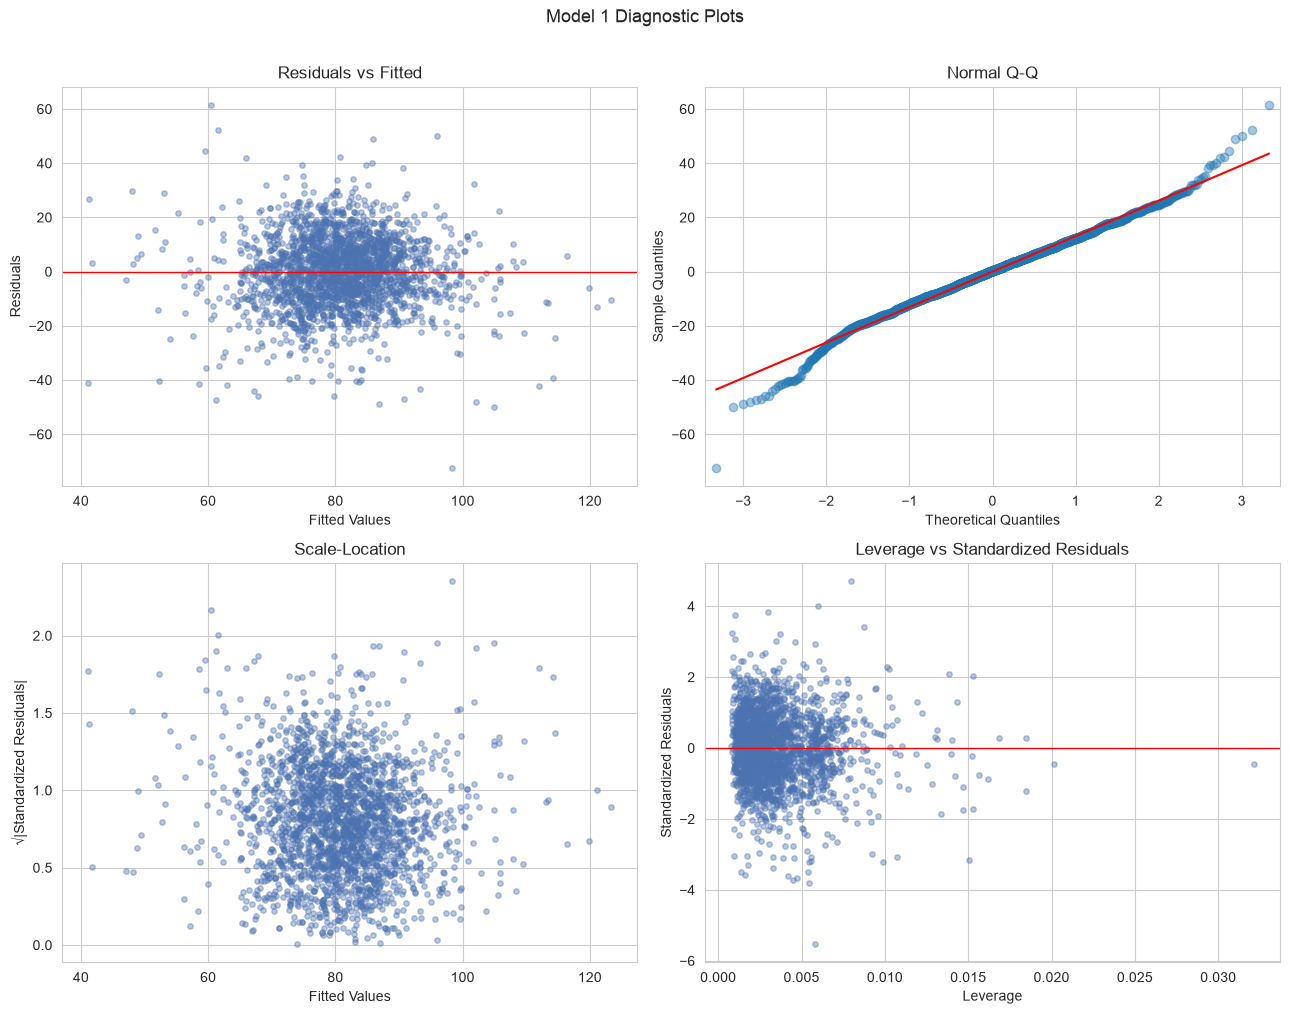

In [17]:
fitted_1 = model_1.fittedvalues
residuals_1 = model_1.resid
std_resid_1 = residuals_1 / residuals_1.std()

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

# Residuals vs Fitted
axes[0,0].scatter(fitted_1, residuals_1, alpha=0.4, color='#4C72B0', s=15)
axes[0,0].axhline(0, color='red', linewidth=1)
axes[0,0].set_xlabel('Fitted Values'); axes[0,0].set_ylabel('Residuals')
axes[0,0].set_title('Residuals vs Fitted')

# Q-Q Plot
sm.qqplot(residuals_1, line='s', ax=axes[0,1], alpha=0.4)
axes[0,1].set_title('Normal Q-Q')

# Scale-location
axes[1,0].scatter(fitted_1, np.sqrt(np.abs(std_resid_1)), alpha=0.4, color='#4C72B0', s=15)
axes[1,0].set_xlabel('Fitted Values'); axes[1,0].set_ylabel('√|Standardized Residuals|')
axes[1,0].set_title('Scale-Location')

# Leverage (hat values) vs Standardized Residuals
influence = model_1.get_influence()
leverage = influence.hat_matrix_diag
axes[1,1].scatter(leverage, std_resid_1, alpha=0.4, color='#4C72B0', s=15)
axes[1,1].axhline(0, color='red', linewidth=1)
axes[1,1].set_xlabel('Leverage'); axes[1,1].set_ylabel('Standardized Residuals')
axes[1,1].set_title('Leverage vs Standardized Residuals')

plt.suptitle('Model 1 Diagnostic Plots', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

**Interpretation**

**1. Residuals vs Fitted**
- Tests two OLS assumptions simultaneously: linearity (is a straight line actually the right functional form?) and homoscedasticity (do the errors have constant variance across the range of predictions?).
- "Good" is roughly a horizontal cloud of points centered on zero, with consistent vertical spread from left to right; no patterns, funnels, or curves.
- Our data shows that the cloud is centered on zero in the middle range (fitted values 60-100), which is good. However, on the left side (fitted values ~40-60), there are large negative residuals. The model predicted ~60 wins but the actual was much lower. This is our < 50 wins bucket. The model systematically over-predicts for very bad teams. On the right side (fitted > 100), we see large positive residuals. The model under-predicts for very good teams. This is the era/distribution issue we hypothesized earlier.

**2. Normal Q-Q Plot**
- Tests whether the residuals are normally distributed, a core OLS assumption required for valid hypothesis tests.
- "Good" looks like points falling tightly along the diagonal red line from corner to corner.
- Our data shows the middle portion follows the line reasonably well, but both tails deviate. The lower-left tail curves below the line (more extreme negative residuals than a normal distribution would produce) and the upper-right tail curves above it (more extreme positive residuals). This is heavy tails or excess kurtosis, confirmed by the Kurtosis = 4.39 in the model output (normal = 3.30). This means our hypothesis tests are slightly less reliable than they would be with perfectly normal errors, though with 2,276 observations, the Central Limit Theorem provides some protection.

**3. Scale-Location (aka Spread-Location)**
- Tests for homoscedasticity more directly than the first plot, specifically whether the magnitude of errors is consistent across fitted values, regardless of sign.
- "Good" would be a flat, horizontal band of points with consistent vertical spread. If the band fans out (funnel shape, wider on the right), we have heteroscedasticity and errros get larger as predictions get larger.
- Our data shows that there's a noticeable downward slope from left to right. The spread of standardized residuals is larger at lower fitted values (~40-60) and narrows toward higher fitted values (~100+). This is heteroscedasticity, and it's the mirror of what we saw in Plot 1: the model is much less precise for low-win teams than for typical teams. This violates a core OLS assumption and suggests our standard errors (and therefore our t-statistics and p-values) may not be fully trustworthy for coefficient inference.

**4. Leverage vs Standardized Residuals**
- Tests for influential observations. Points that have an outsized effect on where the regression line lands:
    - Leverage (x-axis): how unusual is this observation's predictor values compared to the rest of the data? A high-leverage point sits far from the center of the X space and can "pull" the line toward itself.
    - Standardized residual (y-axis): how far is the actual outcome from what the model predicted, in standard deviation units?
- A point in the upper-right or lower-right (high-leverage + large residual) is genuinely dangerous because it's both unusual and poorly fit and could distort our coefficients significantly. These are Cook's Distance points (a point with high leverage but a small residual is unusual in X-space but the model fits it well).
- Our data shows that most points cluster near zero leverage (good - no single observation dominates). But there's a cluster on the right side with leverage ~0.025-0.030 and some with residuals of +-2-4 standard deviations. Those are worth watching (almost certainly the very-low-win and very-high-win era teams again). 

### 1.4 Model 1 - Residual Analysis by Performance Bucket

Requirement: split training data into three performance tiers and analyze model fit within each group, identifying systematic over/under-prediction patterns

| Bucket | Condition |
| --- | --- |
| Bucket 1 | TARGET_WINS < 50 |
| Bucket 2 | TARGET_WINS >= 50 and < 100 |
| Bucket 3 | TARGET_WINS >= 100 |

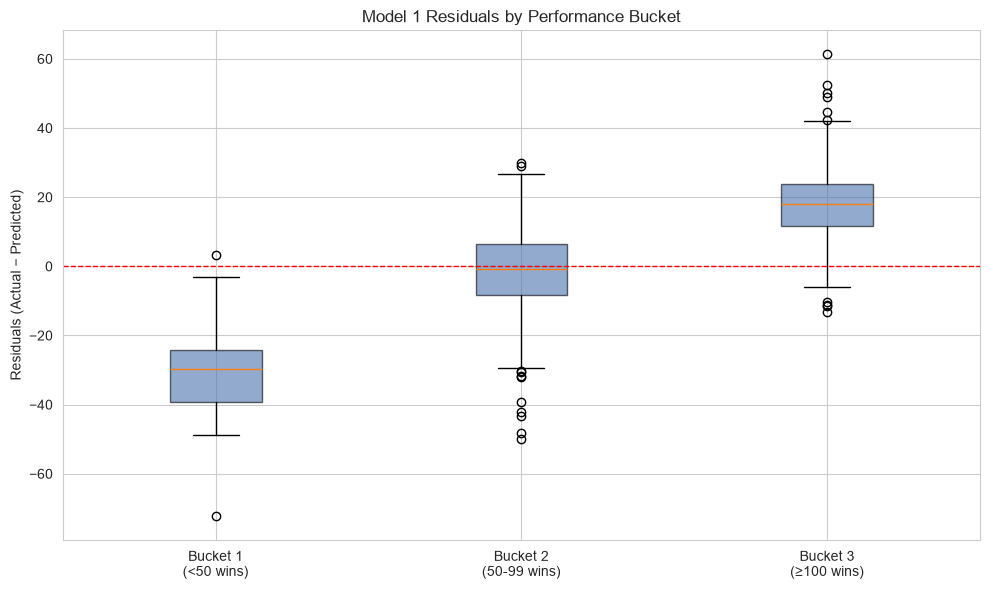

In [20]:
# Assign buckets
bucket_conditions = [
    train_imputed['TARGET_WINS'] < 50,
    (train_imputed['TARGET_WINS'] >= 50) & (train_imputed['TARGET_WINS'] < 100),
    train_imputed['TARGET_WINS'] >= 100
]
bucket_labels = ['Bucket 1\n(<50 wins)', 'Bucket 2\n(50-99 wins)', 'Bucket 3\n(≥100 wins)']

residuals_1 = model_1.resid
bucket_resids = [residuals_1[cond] for cond in bucket_conditions]

# Boxplots
fig, ax = plt.subplots(figsize=(10, 6))
bp = ax.boxplot(bucket_resids, tick_labels=bucket_labels, patch_artist=True,
                boxprops=dict(facecolor='#4C72B0', alpha=0.6))
ax.axhline(0, color='red', linewidth=1, linestyle='--')
ax.set_ylabel('Residuals (Actual − Predicted)')
ax.set_title('Model 1 Residuals by Performance Bucket')
plt.tight_layout()
plt.show()

In [21]:
# Summary statistics per bucket
bucket_names = ['Bucket 1 (<50)', 'Bucket 2 (50-99)', 'Bucket 3 (≥100)']
summary_rows = []
for name, cond in zip(bucket_names, bucket_conditions):
    actual    = train_imputed.loc[cond, 'TARGET_WINS']
    predicted = model_1.fittedvalues[cond]
    resid     = residuals_1[cond]
    summary_rows.append({
        'Bucket': name,
        'N': len(actual),
        'Actual Mean Wins': actual.mean().round(1),
        'Predicted Mean Wins': predicted.mean().round(1),
        'Mean Residual': resid.mean().round(2),
        'Median Residual': resid.median().round(2),
        'Std Residual': resid.std().round(2),
    })

bucket_summary = pd.DataFrame(summary_rows).set_index('Bucket')
print(bucket_summary.to_string())

                     N  Actual Mean Wins  Predicted Mean Wins  Mean Residual  Median Residual  Std Residual
Bucket                                                                                                     
Bucket 1 (<50)      67              39.1                 69.5         -30.38           -29.71         11.84
Bucket 2 (50-99)  1981              79.3                 80.3          -1.05            -0.79         10.44
Bucket 3 (≥100)    228             106.3                 88.3          18.02            17.92         10.73


#### Bucket Analysis Interpretation

**Which bucket shows the best model fit?** Bucket 2 (50-99 wins) by a wide margin. With 1,981 of 2,276 training records (87%), it represents the "typical" team the model was effectively trained to fit. Actual mean wins (79.3) and predicted mean wins (80.3) differ by just 1 game, and the residuals are centered near zero with a median of -0.79. 

**Are any buckets consistently over-predicted?** Bucket 1 (<50 wins) is severely over-predicted. Actual mean = 39.1, predicted mean = 69.5, mean residual = -30.4 wins. The model predicts ~70 wins for teams that actually won ~39. Critically, the predicted values don't stay within bucket boundaries. The model has no knowledge of the post-hoc bucket definitions. It predicts ~70 because the cleaned predictor values for these teams look roughly league-average, even though their actual outcomes were extreme. This is a direct consequence of median imputation: teams from the early/dead-ball era with corrupted or missing pitching and batting columns had those values replaced with league-average medians, masking how unusual those teams truly were. The bucket residual analysis surfaces this failure that overall $R^2$ cannot. 

**Are any buckets consistently under-predicted?** Bucket 3 (>= 100 wins) is consistently under-predicted. Actual mean = 106.3, predicted mean = 88.3, mean residual = +18.0 wins. Elite teams win far more than their predictor values alone suggest. They are likely capturing dynasty effects, extraordinary pitching, or other factors not well-represented in the available variables. The asymmetry between Buckets 1 (-30.4) and 3 (+18.0) reflects that extreme failure is harder for the model to detect than extreme success, partly because the corruption-driven imputation disproportionately affected the worst historical teams. 

**What this means for subsequent models**: a log(TARGET_WINS) response transformation may reduce this heterosceddasticity by compressing the extremes. The same win total difference matters less in log-space at the high end than at the low end. 

### 1.5 Indicator (Dummy) Variables for TARGET_WINS Groups

Five performance groups based on TARGET_WINS, with G3 (75-89 wins) as the reference category. It contains the mean and median of the full distribution, is the largest group (38.6% of training data), and provides the most stable baseline for coefficient interpretation. All other group coefficients are interpreted as "the difference in predicted wins relative to a typical (G3) team, holding all other predictors constant."

| Group | Condition | N | P(X=1) |
| --- | --- | --- | --- | 
| G1 | TARGET_WINS < 50 | 67 | 0.029 |
| G2 | TARGET_WINS 50-74 | 661 | 0.290 |
| G3 (reference) | TARGET_WINS 75-89 | 878 | 0.386 |
| G4 | TARGET_WINS 90-99 | 442 | 0.194 |
| G5 | TARGET_WINS >= 100 | 228 | 0.100 |

P(X=1) is the proportion of training records belonging to each group. It has a precise probabilistic meaning: for a randomly selected team-season from this dataset, P)X=1) is the probability that team falls in that group. G1's P(X=1) = 0.029 means only 2.9% of teams are in the extreme-low bucket. This is a small sample that produces a less stable, wider confidence interval on the G1 coefficient for better-represented groups. 

Important methodological notes: these dummy variables are derived from TARGET_WINS iteself (the response variable). They can only be constructed when the outcome is already known, meaning this model cannot be deployed on test.csv (where TARGET_WINS is unknown). This analysis is conducted on the training data only, to understand where the model fits well and where it systematically fails. It is not carried forward into the score predictions. 

In [24]:
# Create dummy variables; G3 (75-89 wins) is the reference group 
train_dummies = train_imputed.copy()

train_dummies['G1'] = (train_dummies['TARGET_WINS'] < 50).astype(int)
train_dummies['G2'] = ((train_dummies['TARGET_WINS'] >= 50) & (train_dummies['TARGET_WINS'] < 75)).astype(int)
train_dummies['G4'] = ((train_dummies['TARGET_WINS'] >= 90) & (train_dummies['TARGET_WINS'] < 100)).astype(int)
train_dummies['G5'] = (train_dummies['TARGET_WINS'] >= 100).astype(int)
# G3 intentionally omitted

dummy_cols = ['G1', 'G2', 'G4', 'G5']
print("Dummy variable counts and P(X=1):")
for d in dummy_cols: 
    n = train_dummies[d].sum()
    print(f" {d}: n={n}, P(X=1)={n/len(train_dummies):.3f}")
print(f" G3 (reference): n={len(train_dummies) - train_dummies[dummy_cols].sum().sum()}, "
      f"P(X=1)={1 - train_dummies[dummy_cols].sum().sum()/len(train_dummies):.3f}")

Dummy variable counts and P(X=1):
 G1: n=67, P(X=1)=0.029
 G2: n=661, P(X=1)=0.290
 G4: n=442, P(X=1)=0.194
 G5: n=228, P(X=1)=0.100
 G3 (reference): n=878, P(X=1)=0.386


In [25]:
# Refit Model 1 with dummy variables added
dummy_model_cols = MODEL_1_COLS + dummy_cols

X_dummy = sm.add_constant(train_dummies[dummy_model_cols])
y_dummy = train_dummies['TARGET_WINS']
model_dummy = sm.OLS(y_dummy, X_dummy).fit()
print(model_dummy.summary())

                            OLS Regression Results                            
Dep. Variable:            TARGET_WINS   R-squared:                       0.891
Model:                            OLS   Adj. R-squared:                  0.891
Method:                 Least Squares   F-statistic:                     1687.
Date:                Mon, 13 Jul 2026   Prob (F-statistic):               0.00
Time:                        18:48:31   Log-Likelihood:                -6978.8
No. Observations:                2276   AIC:                         1.398e+04
Df Residuals:                    2264   BIC:                         1.405e+04
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const           

#### Dummy Variable Model - Interpretation

Each dummy coefficient represents the average difference in TARGET_WINS relative to the reference group (G3: 75-89 wins), after controlling for all other predictors. We expect G1 and G2 to have negative coefficients (fewer wins than G3 teams) and G4/G5 to have positive coefficients (more wins than G3 teams). Any deviation from this pattern would indicate the other predictors are already capturing most of the group-level variation. 

$R^2 = 0.891$ is a dramatic increase from Model 1's 0.310. This does NOT indicate a better predictive model but instead reflects data leakage. The dummy variables are derived directly from `TARGET_WINS` (the response variable), so the model is partly using the answer to predict itself. This is fundamentally different from overfitting (memorizing noise). Here the inflated $R^2$ comes from encoding direct information about Y into the predictors, not from fitting random fluctuations. 

Dummy coefficients (all relative to G3, the 75-89 win reference group): 
- G1 (< 50 wins): -40.6 - extreme-low-win teams average ~41 fewer wins than G3 teams, holding other predictors constant.
- G2 (50-74 wins): -15.5 - below-average teams average ~16 fewer wins than G3.
- G4 (90-99 wins): +11.3 - above-average teams average ~11 more wins than G3.
- G5 (>= 100 wins): +22.9 - elite teams average ~23 more wins than G3.

**Why did adding dummies shrink the other coefficients?** In Model 1, `OFFENSE_PROXY` explained genuine within-team batting variation and proxying for win-tier membership (since high-offense teams tend to be high-win teams). Once the dummies explicitly encode win-tier, `OFFENSE_PROXY`'s coefficient shrinks from 0.268 to 0.0054. It now only explains within-tier variation. This is omitted variable bias in reverse: Model 1's coefficients were upward-biased because win-tier was an omitted variable implicitly correlated with every predictor. 

All original predictors remain statistically significant even after the dummies absorb 89% of variance, confirming they capture real within-tier signal. 

**This model is used for training-data analysis only and is excluded from the model comparison table and all scored predictions.**

### 1.6 Model 2 - Truncated Variable Model

Assignment specifies a truncated batting hits variable: 

`trunc_team_batting = TEAM_BATTING_H`
`if TEAM_BATTING_H < 1122: trunc_team_batting = 1122`
`if TEAM_BATTING_H > 2333: trunc_team_batting = 2333`

This caps extreme values rather than replacing them with the median (as in MA #1's repair approach). Unlike median imputation, truncation preserves the relative ordering of extreme observations (a team with 2,500 hits is still recognized as high-hit team (capped at 2,333) rather than being pulled to the median (~1,474)). 

`TEAM_BATTING_H` was not flagged for repair in MA #1 (zero missing values, no corruption) so this is a different use case: managing legitimate extreme performances that may pull the regression line disproportionately, rather than fixing corrupted data. 

**Desicion**: `trunc_team_batting` replaces `OFFENSE_PROXY` in this model (since both are batting-centered measures built from overlapping variables, including them together would recreate the multicollinearity problem diagnozed in MA #1). Models 1 and 2 are therefore non-nested (AIC, BIC, and Adjusted $R^2$ are used for comparison rather than a nested F-test). 

In [28]:
# Create truncated variable
train_imputed['TRUNC_TEAM_BATTING'] = train_imputed['TEAM_BATTING_H'].clip(lower=1122, upper=2333)

print("TEAM_BATTING_H vs TRUNC_TEAM_BATTING:")
compare = pd.DataFrame({
    'BATTING_H': train_imputed['TEAM_BATTING_H'],
    'TRUNC_BATTING': train_imputed['TRUNC_TEAM_BATTING']
}).describe().round(1)
print(compare)
print()
n_capped_low = (train_imputed['TEAM_BATTING_H'] < 1122).sum()
n_capped_high = (train_imputed['TEAM_BATTING_H'] > 2333).sum()
print(f"Records capped at lower bound (1122): {n_capped_low}")
print(f"Records capped at upper bound (2333): {n_capped_high}")

TEAM_BATTING_H vs TRUNC_TEAM_BATTING:
       BATTING_H  TRUNC_BATTING
count     2276.0         2276.0
mean      1469.3         1469.3
std        144.6          142.7
min        891.0         1122.0
25%       1383.0         1383.0
50%       1454.0         1454.0
75%       1537.2         1537.2
max       2554.0         2333.0

Records capped at lower bound (1122): 4
Records capped at upper bound (2333): 4


In [29]:
MODEL_2_COLS = ['TRUNC_TEAM_BATTING', 'LOW_HR_ERA', 'TEAM_FIELDING_E_LOG', 
                'TEAM_BATTING_HBP_WAS_MISSING', 'TEAM_BATTING_SO', 
                'TEAM_BASERUN_SB', 'TEAM_FIELDING_DP']

X2 = sm.add_constant(train_imputed[MODEL_2_COLS])
model_2 = sm.OLS(y, X2).fit()
print(model_2.summary())

                            OLS Regression Results                            
Dep. Variable:            TARGET_WINS   R-squared:                       0.236
Model:                            OLS   Adj. R-squared:                  0.234
Method:                 Least Squares   F-statistic:                     100.3
Date:                Mon, 13 Jul 2026   Prob (F-statistic):          4.75e-128
Time:                        18:48:31   Log-Likelihood:                -9196.8
No. Observations:                2276   AIC:                         1.841e+04
Df Residuals:                    2268   BIC:                         1.846e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const           

In [30]:
# VIF for Model 2
Xv2 = train_imputed[MODEL_2_COLS].assign(const=1)
vif2 = pd.Series(
    [variance_inflation_factor(Xv2.values, i) for i in range(len(MODEL_2_COLS))],
    index=MODEL_2_COLS
).sort_values(ascending=False).round(2)
print("Model 2 VIF:")
print(vif2)

Model 2 VIF:
TEAM_FIELDING_E_LOG             3.01
TEAM_BATTING_SO                 2.72
LOW_HR_ERA                      2.67
TEAM_BASERUN_SB                 1.60
TRUNC_TEAM_BATTING              1.34
TEAM_BATTING_HBP_WAS_MISSING    1.28
TEAM_FIELDING_DP                1.20
dtype: float64


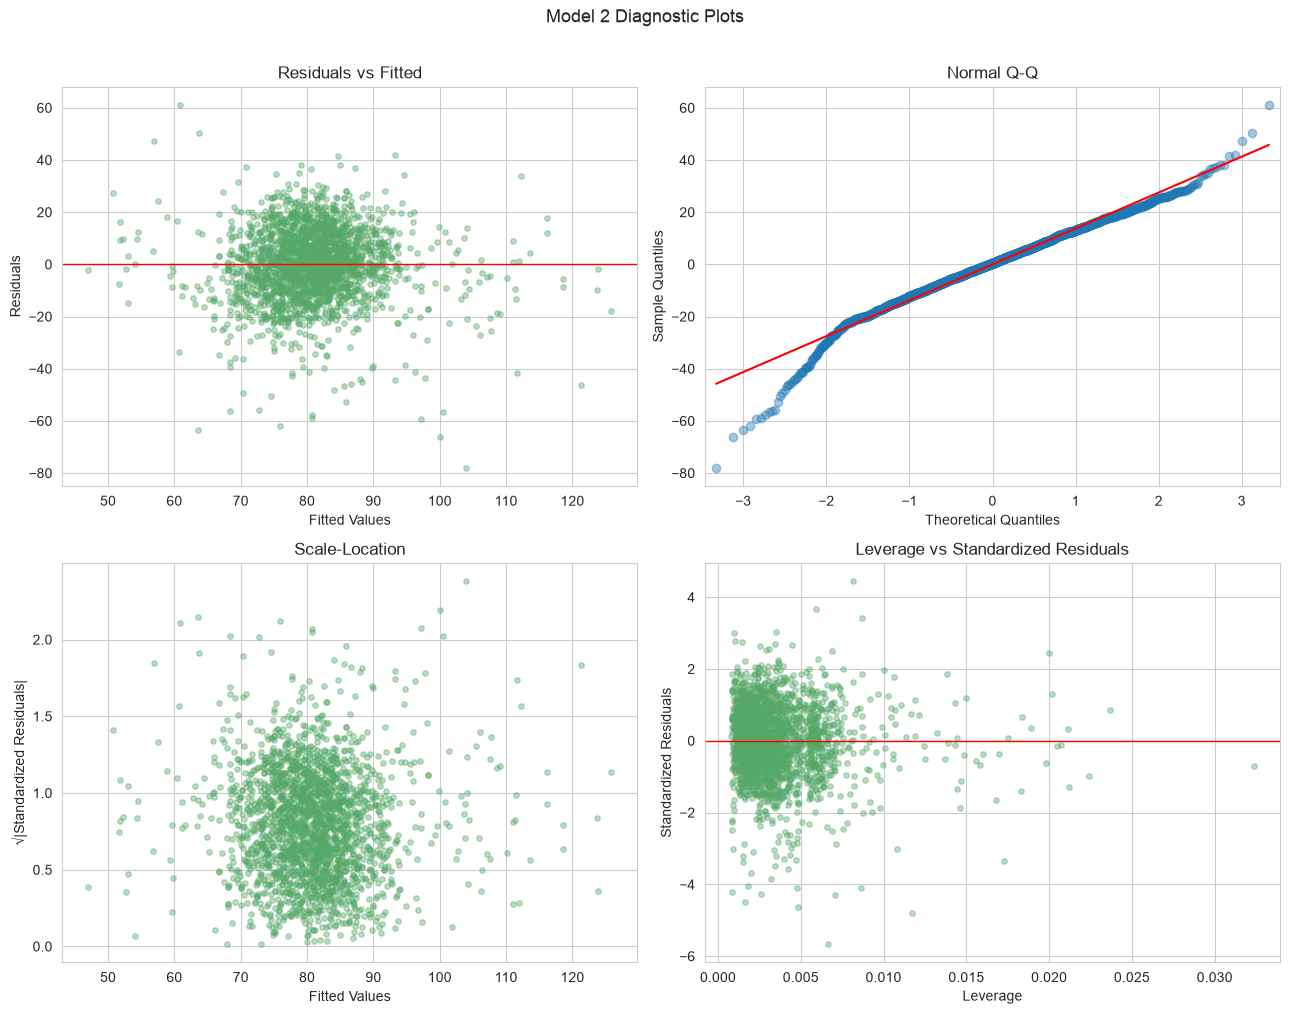

In [31]:
# Model 2 diagnostic plots
fitted_2    = model_2.fittedvalues
residuals_2 = model_2.resid
std_resid_2 = residuals_2 / residuals_2.std()

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

axes[0,0].scatter(fitted_2, residuals_2, alpha=0.4, color='#55A868', s=15)
axes[0,0].axhline(0, color='red', linewidth=1)
axes[0,0].set_xlabel('Fitted Values'); axes[0,0].set_ylabel('Residuals')
axes[0,0].set_title('Residuals vs Fitted')

sm.qqplot(residuals_2, line='s', ax=axes[0,1], alpha=0.4)
axes[0,1].set_title('Normal Q-Q')

axes[1,0].scatter(fitted_2, np.sqrt(np.abs(std_resid_2)), alpha=0.4, color='#55A868', s=15)
axes[1,0].set_xlabel('Fitted Values'); axes[1,0].set_ylabel('√|Standardized Residuals|')
axes[1,0].set_title('Scale-Location')

influence_2 = model_2.get_influence()
leverage_2  = influence_2.hat_matrix_diag
axes[1,1].scatter(leverage_2, std_resid_2, alpha=0.4, color='#55A868', s=15)
axes[1,1].axhline(0, color='red', linewidth=1)
axes[1,1].set_xlabel('Leverage'); axes[1,1].set_ylabel('Standardized Residuals')
axes[1,1].set_title('Leverage vs Standardized Residuals')

plt.suptitle('Model 2 Diagnostic Plots', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

#### Model 2 Results & Interpretation

**Truncation had minimal impact on the data**: only 4 records were capped at the lower bound (1,122) and 4 at the upper bound (2,333), just 0.35% of training records. Mean and standard deviation are nearly identical to the raw column (1,469 vs 1,469; 144.6 vs 142.7). `TEAM_BATTING_H` does not have many extreme values requiring correction, making truncation largely a no-op for this particular variable. 

**$R^2 = 0.236$ was worse than Model 1 (0.310)**. This is expected given what `TRUNC_TEAM_BATTING` is replacing: `OFFENSE_PROXY` combines five batting components (H, 2B, 3B, HR, BB) weighted by extra bases. This is an approximation of run-scoring power. `TRUNC_TEAM_BATTING` is just raw hit counts with 8 extreme values capped. Hits alone are a weaker signal for wins than a weighted combination of hit types, because a single and a home run both counts as 1 hit but have very different run-production implications. 

**`LOW_HR_ERA` became completely insignificant** (coef = 0.16, p = 0.872) after removing `OFFENSE_PROXY`. In Model 1, `OFFENSE_PROXY` included `TEAM_BATTING_HR` (weighted at 3 extra bases above a single), which was the variable most correlated to the dead-ball vs. live-ball era split. Once that HR component is removed from the batting measure, the model loses its primary mechanism for distinguishing era-level offense environments through the batting side. `LOW_HR_ERA` attempts to fill that gap but its signal is now absorbed inconsistently with no collinear partner, producing an unstable, insignificant coefficient. 

**All VIFs are clean (max 3.01)**: the truncated model has no multicollinearity concerns. 

**Diagnostic plots**: the same heteroscedasticity pattern from Model 1 persists (wider spread at low fitted values), with the lower-tail Q-Q deviation more pronounced than Model 1's, suggesting the truncated model handles extreme-low-win teams even less well, consistent with the lower $R^2$. 

**Conclusion**: Model 2 confirms that `OFFENSE_PROXY`'s multi-component weighting is more informative for predicting wins than raw hits.

### 1.7 Model 3 - Log(TARGET_WINS) Response Transformation

The bucket residual analysis showed severe heteroscedasticity. The model over-predicts Bucket 1 teams by ~30 wins and under-predicts Bucket 3 teams by ~18 wins. The diagnostic plots confirmed the spread of residuals is wider at low fitted values than at high one. A log transformation of the response variable compresses the upper tail and expands the lower tail, which may reduce this heteroscedasticity and improve fit at the extremes. 

**Coefficient interpretation changes**: in a log(Y) model, a coefficient $\beta$ means a one-unit increase in the predictor is associated with approximately $\beta$ x 100% change in TARGET_WINS (proportional, not absolute). Example: if `OFFENSE_PROXY` has $\beta = 0.0003$, one additional unit of offensive production is associated with a ~0.03% increase in wins. 

**Comparison note**: $R^2$ cannot be directly compared between this model and Models 1/2 because they measure variance explained in log(TARGET_WINS) vs TARGET_WINS respectively, which are different quantities. RMSE on the original wins scale (after back-tranforming predictions via exp()) is used for direct performance comparison. 

In [34]:
# Response transformation - log(TARGET_WINS)
# One record has TARGET_WINS = 0, same corruption artifact as the extreme TEAM_PITCHING_H = 24,057 found in MA #1. 
# Per the project's "repair, don't delete" principle, we replace it with the median TARGET_WINS (82.0) before log-tranforming. Impact is negligible

FROZEN_TARGET_WINS_MEDIAN = train_imputed['TARGET_WINS'][train_imputed['TARGET_WINS'] > 0].median()
print(f"Median TARGET_WINS (non-zero): {FROZEN_TARGET_WINS_MEDIAN}")
print(f"Records with TARGET_WINS = 0: {(train_imputed['TARGET_WINS'] == 0).sum()}")

train_imputed['TARGET_WINS_CLEAN'] = train_imputed['TARGET_WINS'].replace(0, FROZEN_TARGET_WINS_MEDIAN)
train_imputed['LOG_TARGET_WINS'] = np.log(train_imputed['TARGET_WINS_CLEAN'])

print(f"\nInf values in LOG_TARGET_WINS after repair: {np.isinf(train_imputed['LOG_TARGET_WINS']).sum()}")
print("LOG_TARGET_WINS summary:")
print(train_imputed['LOG_TARGET_WINS'].describe().round(3))

Median TARGET_WINS (non-zero): 82.0
Records with TARGET_WINS = 0: 1

Inf values in LOG_TARGET_WINS after repair: 0
LOG_TARGET_WINS summary:
count    2276.000
mean        4.371
std         0.220
min         2.485
25%         4.263
50%         4.407
75%         4.522
max         4.984
Name: LOG_TARGET_WINS, dtype: float64


In [35]:
# Model 3: same predictors as Model 1, log(TARGET_WINS) as response
MODEL_3_COLS = MODEL_1_COLS

y_log = train_imputed['LOG_TARGET_WINS']
X3 = sm.add_constant(train_imputed[MODEL_3_COLS])
model_3 = sm.OLS(y_log, X3).fit()
print(model_3.summary())

                            OLS Regression Results                            
Dep. Variable:        LOG_TARGET_WINS   R-squared:                       0.287
Model:                            OLS   Adj. R-squared:                  0.285
Method:                 Least Squares   F-statistic:                     130.5
Date:                Mon, 13 Jul 2026   Prob (F-statistic):          1.10e-161
Time:                        18:48:31   Log-Likelihood:                 599.23
No. Observations:                2276   AIC:                            -1182.
Df Residuals:                    2268   BIC:                            -1137.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const           

In [36]:
# VIF for Model 3 (same predictors as Model 1)
Xv3 = train_imputed[MODEL_3_COLS].assign(const=1)
vif3 = pd.Series(
    [variance_inflation_factor(Xv3.values, i) for i in range(len(MODEL_3_COLS))],
    index=MODEL_3_COLS
).sort_values(ascending=False).round(2)
print("Model 3 VIF:")
print(vif3)

Model 3 VIF:
TEAM_FIELDING_E_LOG             3.14
LOW_HR_ERA                      2.81
TEAM_BATTING_SO                 2.32
OFFENSE_PROXY                   1.72
TEAM_BASERUN_SB                 1.60
TEAM_BATTING_HBP_WAS_MISSING    1.32
TEAM_FIELDING_DP                1.28
dtype: float64


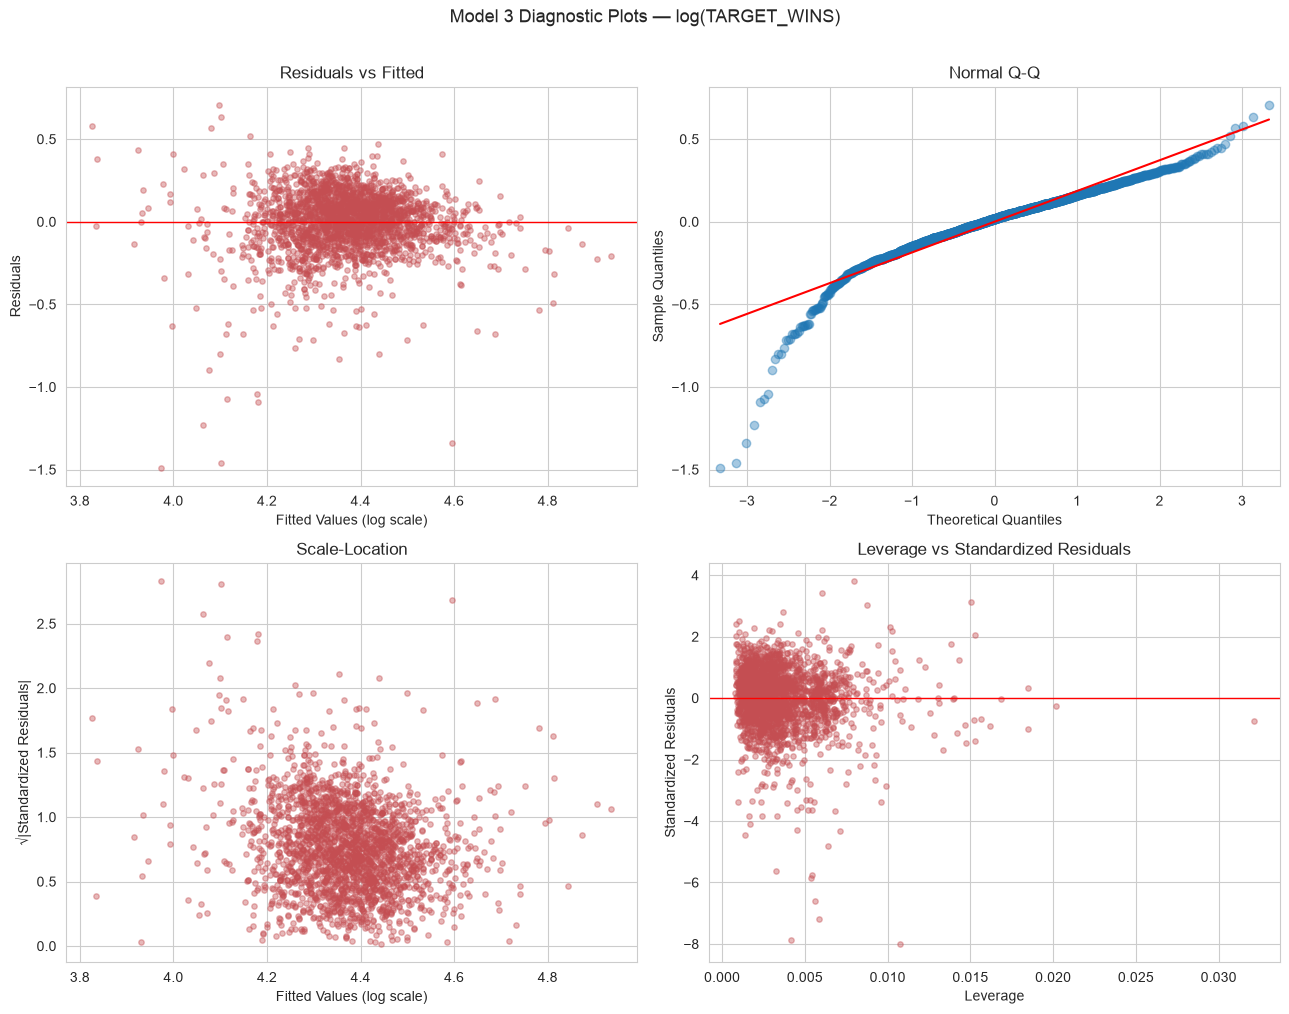

In [37]:
# Diagnostic plots for Model 3
fitted_3    = model_3.fittedvalues
residuals_3 = model_3.resid
std_resid_3 = residuals_3 / residuals_3.std()

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

axes[0,0].scatter(fitted_3, residuals_3, alpha=0.4, color='#C44E52', s=15)
axes[0,0].axhline(0, color='red', linewidth=1)
axes[0,0].set_xlabel('Fitted Values (log scale)'); axes[0,0].set_ylabel('Residuals')
axes[0,0].set_title('Residuals vs Fitted')

sm.qqplot(residuals_3, line='s', ax=axes[0,1], alpha=0.4)
axes[0,1].set_title('Normal Q-Q')

axes[1,0].scatter(fitted_3, np.sqrt(np.abs(std_resid_3)), alpha=0.4, color='#C44E52', s=15)
axes[1,0].set_xlabel('Fitted Values (log scale)'); axes[1,0].set_ylabel('√|Standardized Residuals|')
axes[1,0].set_title('Scale-Location')

influence_3 = model_3.get_influence()
leverage_3  = influence_3.hat_matrix_diag
axes[1,1].scatter(leverage_3, std_resid_3, alpha=0.4, color='#C44E52', s=15)
axes[1,1].axhline(0, color='red', linewidth=1)
axes[1,1].set_xlabel('Leverage'); axes[1,1].set_ylabel('Standardized Residuals')
axes[1,1].set_title('Leverage vs Standardized Residuals')

plt.suptitle('Model 3 Diagnostic Plots — log(TARGET_WINS)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [38]:
# RMSE comparison on original wins scale
# Back-transform Model 3 predictions via exp() for fair comparison
pred_m1 = model_1.fittedvalues
pred_m3_bt = np.exp(model_3.fittedvalues)

rmse_m1 = np.sqrt(((train_imputed['TARGET_WINS'] - pred_m1)**2).mean())
rmse_m3 = np.sqrt(((train_imputed['TARGET_WINS'] - pred_m3_bt)**2).mean())

print(f"Model 1 RMSE (wins scale): {rmse_m1:.3f}")
print(f"Model 3 RMSE (wins scale, back-transformed): {rmse_m3:.3f}")
print()

# Bucket-level residuals for Model 3 (back-transformed)
resid_m3_bt = train_imputed['TARGET_WINS'] - pred_m3_bt
print("Model 3 back-transformed residuals by bucket:")
for name, cond in zip(bucket_names, bucket_conditions):
    print(f" {name}: mean residual = {resid_m3_bt[cond].mean():.2f} "
          f"(Model 1 was: {residuals_1[cond].mean():.2f})")

Model 1 RMSE (wins scale): 13.080
Model 3 RMSE (wins scale, back-transformed): 13.321

Model 3 back-transformed residuals by bucket:
 Bucket 1 (<50): mean residual = -29.12 (Model 1 was: -30.38)
 Bucket 2 (50-99): mean residual = 0.20 (Model 1 was: -1.05)
 Bucket 3 (≥100): mean residual = 18.30 (Model 1 was: 18.02)


#### Model 3 Results & Interpretation

**$R^2 = 0.287$ on log(TARGET_WINS)**: Not directly comparable to Models 1/2 since the response is on a different scale. Comparison is made via RMSE on the original wins scale after back-transforming predictions using exp(). 

**Coefficient interpretation (proportional, not absolute)**: Each coefficient now represents the approximate *percentage change* in TARGET_WINS per one-unit increase in the predictor: 
- `OFFENSE_PROXY`: $\beta = 0.0004$ -> each additional unit of offensive production is associated with a ~0.04% increase in wins
- `LOW_HR_ERA`: $\beta = 0.0696$ -> dead-ball era teams win approximately 7.2% more wins than modern teams (exp(0.0696) - 1 = 0.072), holding other predictors constant
- `TEAM_FIELDING_E_LOG`: $\beta = -0.162$ -> a 1% increase in errors is associated with approximately a 0.162% decrease in wins (log-log relationship, interpreted as elasticity)

All predictors remain significant and correctly signed. VIFs are identical to Model 1 (same predictors, only Y changed). 

**Did log(TARGET_WINS) improve fit?**
| Metric | Model 1 (raw Y) | Model 3 (log Y) | 
| --- | --- | --- |
| RMSE (wins scale) | 13.080 | 13.321 |
| Bucket 1 mean residual | -30.38 | -29.12 |
| Bucket 2 mean residual | -10.5 | +0.20 |
| Bucket 3 mean residual | 18.02 | 18.30 | 

**The log transofrmation did not materially improve fit**. RMSE is marginally worse, and the extreme bucket residuals are nearly unchanged. The theoretical rationale for log(Y) reducing heteroscedasticity is sound but it only changes how the response variable is scaled, not the predictor values. The fundamental problem is on the X side: after median imputation, Bucket 1 and Bucket 3 teams have predictor profiles that look league-average, even though their actual outcomes are extreme. No amount of Y-side transformation can recover information that was lost when corrupted or missing predictor values were replaced with overall medians. 

**A better fix would be stratified imputation**. Filling missing predictor values usijng medians computed within similar-win-total teams rather than across the full dataset. This would better preserve the unusual predictor profiles of historically extreme teams. The limitation is that stratified imputation requires knowing TARGET_WINS to assign teams to strata, creating data leakage on test data where wins are unknown. This is flagged as a candidate for refinement. 

**When is log(Y) beneficial in general?** Log-transforming the response is most useful when: 1) the response is strictly positive and right-skewed; 2) the relationship between predictors and Y is multiplicative rather than additive; 3) percentage-change interpretations are more meaningful than absolute-unit interpretations; or 4) residual variance grows proportionally with fitted values (heteroscedasticity). Here, condition 4 appears to hold in the diagnostic plots, but the underlying cause (mismeasured X for extreme teams) limits how much Y-transformation can help. 

**Diagnostic plots**: the Q-Q plot shows improvement in the right tail but persistent deviations in the lower-left tail. This is consistent with the interpretation that low-win teams (whose predictor values were normalized by iomputation) remain the primary source of non-normality. 

### 1.8 Model 4 - Best Candidate

Builds directly on Model 1, replacing `OFFENSE_PROXY` with a richer offensive composite `TEAM_BASES_EARNED` that incorporates:
- Truncated 2B, 3B, HR components (caps extreme values within the composite rather than in raw columns)
- Combined walks + HBP (`TEAM_BATTING_BB_HBP`)
- Baserunning (SB, CS) folded into the offensive model, removing them as standalone predictors to avoid partial-overlap multicollinearity
- Missing-indicator flags for CS and SB (`FIX_TEAM_BASERUN_CS`, `FIX_TEAM_BASERUN_SB`) consistent with the HBP flag approach established in MA #1

**Imputation values**: frozen training medians from the Section 0 pipeline are used (CS=49, SB=101). 

**Nested model status**: Model 4 and Model 1 share 5 predictors but differ in their batting representation (`TEAM_BASES_EARNED` vs `OFFENSE_PROXY`) and baserunning treatment (folded in vs standalone). They are non-nested. AIC, BIC, and Adjusted $R^2$ are used for comparison, consistent with the Model 1 and Model 2 comparison approach. 


In [69]:
# Truncated components (applied before computing composite)
train_imputed['TRUNC_BATTING_2B'] = train_imputed['TEAM_BATTING_2B'].clip(lower=123, upper=382)
train_imputed['TRUNC_BATTING_3B'] = train_imputed['TEAM_BATTING_3B'].clip(lower=11, upper=166)
train_imputed['TRUNC_BATTING_HR'] = train_imputed['TEAM_BATTING_HR'].clip(lower=30, upper=240)

# Singles = H minus extra-base hits (avoids double-counting)
train_imputed['TEAM_BATTING_1B'] = (train_imputed['TEAM_BATTING_H']
                                    - train_imputed['TRUNC_BATTING_2B']
                                    - train_imputed['TRUNC_BATTING_3B']
                                    - train_imputed['TRUNC_BATTING_HR'])

# Combined BB + HBP (using frozen-median-imputed HBP)
train_imputed['TEAM_BATTING_BB_HBP'] = (train_imputed['TEAM_BATTING_BB']
                                        + train_imputed['TEAM_BATTING_HBP'])

# Missing-indicator flags for CS and SB (frozen medians already applied in Section 0)
train_imputed['FIX_TEAM_BASERUN_CS'] = train_clean['TEAM_BASERUN_CS'].isna().astype(int)
train_imputed['FIX_TEAM_BASERUN_SB'] = train_clean['TEAM_BASERUN_SB'].isna().astype(int)

# TEAM_BASES_EARNED composit
train_imputed['TEAM_BASES_EARNED'] = (
    4 * train_imputed['TRUNC_BATTING_HR']
    + 3 * train_imputed['TRUNC_BATTING_3B']
    + 2 * train_imputed['TRUNC_BATTING_2B']
    + 1 * train_imputed['TEAM_BATTING_1B']
    + 1 * train_imputed['TEAM_BATTING_BB_HBP']
    + 1 * train_imputed['TEAM_BASERUN_SB']
    - 1 * train_imputed['TEAM_BASERUN_CS']
)

print("TEAM_BASES_EARNED vs OFFENSE_PROXY:")
compare = train_imputed[['OFFENSE_PROXY', 'TEAM_BASES_EARNED']].describe().round(1)
print(compare)
print()
print(f"Correlation between TEAM_BASES_EARNED and OFFENSE_PROXY: "
      f"{train_imputed[['TEAM_BASES_EARNED', 'OFFENSE_PROXY']].corr().iloc[0,1]:.3f}")
print(f"Correlation with TARGET_WINS - OFFENSE_PROXY: "
      f"{train_imputed[['OFFENSE_PROXY', 'TARGET_WINS']].corr().iloc[0,1]:.3f}")
print(f"Correlation with TARGET_WINS - TEAM_BASES_EARNED: "
      f"{train_imputed[['TEAM_BASES_EARNED', 'TARGET_WINS']].corr().iloc[0,1]:.3f}")

TEAM_BASES_EARNED vs OFFENSE_PROXY:
       OFFENSE_PROXY  TEAM_BASES_EARNED
count         2276.0             2276.0
mean          2639.8             2773.5
std            306.6              303.8
min           1353.0             1433.0
25%           2443.0             2573.5
50%           2646.5             2770.0
75%           2839.0             2956.0
max           3787.0             4158.0

Correlation between TEAM_BASES_EARNED and OFFENSE_PROXY: 0.959
Correlation with TARGET_WINS - OFFENSE_PROXY: 0.439
Correlation with TARGET_WINS - TEAM_BASES_EARNED: 0.473


In [71]:
MODEL_4_COLS = ['TEAM_BASES_EARNED', 'LOW_HR_ERA', 'TEAM_FIELDING_E_LOG',
                'TEAM_BATTING_HBP_WAS_MISSING', 'TEAM_BATTING_SO', 'TEAM_FIELDING_DP',
                'FIX_TEAM_BASERUN_CS', 'FIX_TEAM_BASERUN_SB']

X4 = sm.add_constant(train_imputed[MODEL_4_COLS])
model_4 = sm.OLS(y, X4).fit()
print(model_4.summary())

                            OLS Regression Results                            
Dep. Variable:            TARGET_WINS   R-squared:                       0.319
Model:                            OLS   Adj. R-squared:                  0.317
Method:                 Least Squares   F-statistic:                     133.0
Date:                Mon, 13 Jul 2026   Prob (F-statistic):          3.22e-183
Time:                        19:08:51   Log-Likelihood:                -9066.1
No. Observations:                2276   AIC:                         1.815e+04
Df Residuals:                    2267   BIC:                         1.820e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const           

In [75]:
# VIF for Model 4
Xv4 = train_imputed[MODEL_4_COLS].assign(const=1)
vif4 = pd.Series(
    [variance_inflation_factor(Xv4.values, i) for i in range(len(MODEL_4_COLS))],
    index=MODEL_4_COLS
).sort_values(ascending=False).round(2)
print("Model 4 VIF:")
print(vif4)

Model 4 VIF:
LOW_HR_ERA                      3.00
TEAM_FIELDING_E_LOG             2.86
FIX_TEAM_BASERUN_CS             2.37
TEAM_BATTING_SO                 2.22
TEAM_BASES_EARNED               1.43
FIX_TEAM_BASERUN_SB             1.42
TEAM_FIELDING_DP                1.37
TEAM_BATTING_HBP_WAS_MISSING    1.32
dtype: float64


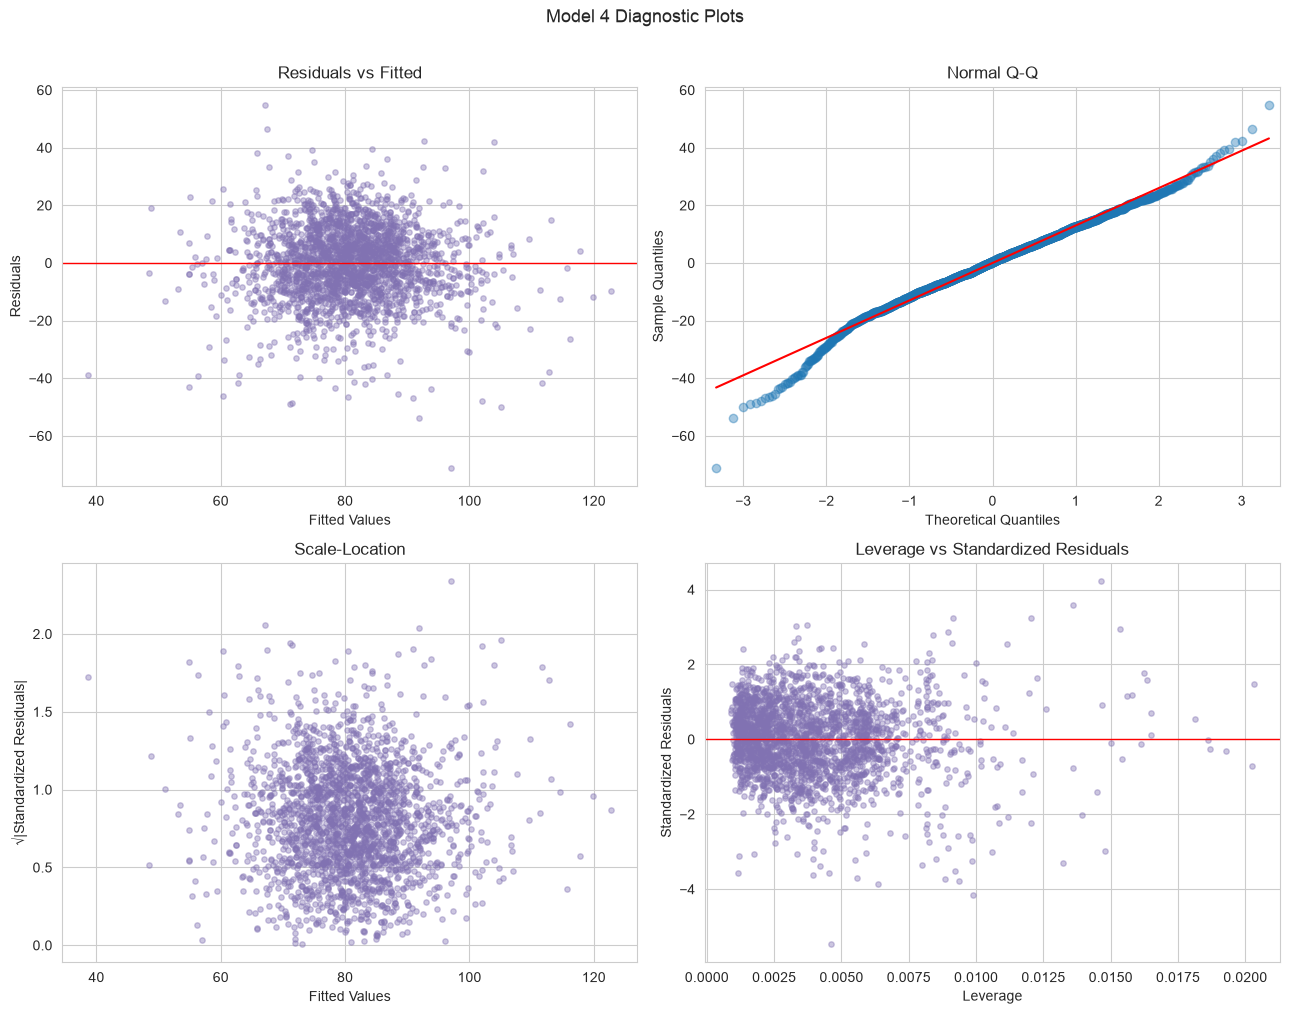

In [77]:
# Diagnostic plots for Model 4
fitted_4 = model_4.fittedvalues
residuals_4 = model_4.resid
std_resid_4 = residuals_4 / residuals_4.std()

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

axes[0,0].scatter(fitted_4, residuals_4, alpha=0.4, color='#8172B2', s=15)
axes[0,0].axhline(0, color='red', linewidth=1)
axes[0,0].set_xlabel('Fitted Values'); axes[0,0].set_ylabel('Residuals')
axes[0,0].set_title('Residuals vs Fitted')

sm.qqplot(residuals_4, line='s', ax=axes[0,1], alpha=0.4)
axes[0,1].set_title('Normal Q-Q')

axes[1,0].scatter(fitted_4, np.sqrt(np.abs(std_resid_4)), alpha=0.4, color='#8172B2', s=15)
axes[1,0].set_xlabel('Fitted Values'); axes[1,0].set_ylabel('√|Standardized Residuals|')
axes[1,0].set_title('Scale-Location')

influence_4 = model_4.get_influence()
leverage_4  = influence_4.hat_matrix_diag
axes[1,1].scatter(leverage_4, std_resid_4, alpha=0.4, color='#8172B2', s=15)
axes[1,1].axhline(0, color='red', linewidth=1)
axes[1,1].set_xlabel('Leverage'); axes[1,1].set_ylabel('Standardized Residuals')
axes[1,1].set_title('Leverage vs Standardized Residuals')

plt.suptitle('Model 4 Diagnostic Plots', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [83]:
# RMSE for Model 4
pred_m4 = model_4.fittedvalues
rmse_m4 = np.sqrt(((train_imputed['TARGET_WINS'] - pred_m4)**2).mean())
rmse_m2_raw = np.sqrt(((train_imputed['TARGET_WINS'] - model_2.fittedvalues)**2).mean())

print("RMSE Comparison (wins scale):")
print(f"  Model 1 (OFFENSE_PROXY baseline):  {rmse_m1:.3f}")
print(f"  Model 2 (truncated hits):           {rmse_m2_raw:.3f}")
print(f"  Model 3 (log Y, back-transformed):  {rmse_m3:.3f}")
print(f"  Model 4 (TEAM_BASES_EARNED):        {rmse_m4:.3f}")

print()
print("Model 4 bucket residuals:")
resid_m4 = train_imputed['TARGET_WINS'] - pred_m4
for name, cond in zip(bucket_names, bucket_conditions):
    print(f"  {name}: mean residual = {resid_m4[cond].mean():.2f}  "
          f"(Model 1: {residuals_1[cond].mean():.2f})")

RMSE Comparison (wins scale):
  Model 1 (OFFENSE_PROXY baseline):  13.080
  Model 2 (truncated hits):           13.761
  Model 3 (log Y, back-transformed):  13.321
  Model 4 (TEAM_BASES_EARNED):        12.993

Model 4 bucket residuals:
  Bucket 1 (<50): mean residual = -31.56  (Model 1: -30.38)
  Bucket 2 (50-99): mean residual = -0.90  (Model 1: -1.05)
  Bucket 3 (≥100): mean residual = 17.11  (Model 1: 18.02)


#### Model 4 Results & Interpretation

$R^2$ = 0.319, Adjusted $R^2$ = 0.317 is the best of all four models on the training data. RMSE = 12.993 is marginally better than Model 1 (13.080) and meaningfully better than Models 2 and 3. 

`TEAM_BASES_EARNED` outperforms `OFFENSE_PROXY` as a batting composite: correlation with `TARGET_WINS` is 0.473 vs 0.439, driven by three components: truncated components controlling for extreme values within the composite, combined BB+HBP capturing base-reaching ability more completely, and baserunning (SB minus CS) folding net steal value directly into the offensive total. SB and CS are excluded as standalone predictors to avoid partial-overlap multicollinearity (the same principle that motivated replacing raw batting components with `OFFENSE_PROXY` in MA #1). 

**Coefficient signs and magnitudes**: 
- `TEAM_BASES_EARNED` (+0.0303): more offensive production = more wins
- `LOW_HR_ERA` (+5.84): era flag works as expected
- `TEAM_FIELDING_E_LOG` (-11.47): more errors = fewer wins
- `TEAM_BATTING_HBP_WAS_MISSING`: (+7.19): era signal, consistent with MA #1
- `TEAM_BATTIN_SO` (-0.0101): more strikeouts = fewer wins
- `TEAM_FIELDING_DP` (-0.128): more opportunity-dependent sta, negative as expected
- `FIX_TEAM_BASERUN_SB` (+5.75, p < 0.001): teams where SB was originally missing win more = consistent with the era signal captured by similar flags
- `FIX_TEAM_BASERUN_CS` (+1.40, p = 0.115): **retained despite marginal significance**. The same rationale applies as for HBP_WAS_MISSING. Whether caught stealing was officially tracked is an era indicator. The coefficient is directionally consistent and the VIF (2.37) shows no collinearity concern. Dropped in a future refinement pass if significance doesn't improve.

**All VIFs below 3.01**: cleanest multicollinearity profile of any model

**Diagnostic plots**: residual pattern is similar to Model 1. The heteroscedasticity at extreme fitted values persist, confirming again that the limitation is in the X side (imputed predictor values for extreme-era teams) rather than the model specification. Leverage plot shows reduced maximum leverage vs Model 1 (0.020 vs 0.030), suggesting `TEAM_BASES_EARNED` distributes influence more evenly than `OFFENSE_PROXY`. 

**Model 4 is selected as the final model** for scored predictions. 

---
## Section 2: Model Comparison - Y vs log(Y)

### 2.1 Coefficient Interpretation

**Model 1 (TARGET_WINS as response)**: Coefficients represent absolute unit changes in wins. For example, the `OFFENSE_PROXY` coefficient of 0.0268 means each additional unit of offensive production is associate with 0.0268 more wins, holding all other predictors constant. Intercepts and coefficients are directly interpretable in game units (a baseball analyst can immediately understand "one more stolen base = 0.041 more expected wins.")

**Model 3 (log(TARGET_WINS) as response)**: Coefficients represent approximate percentage changes in wins. For example, the `OFFENSE_PROXY` coefficient of 0.0004 means each additional unit of offensive production is asosciated with approximately 0.04% more wins. For larger coefficients, the precise interpretation is exp($\beta$) - 1: `LOW_HR_ERA` $\beta$ = 0.0696 -> exp(0.0696) - 1 = 7.2% more wins for dead-ball era teams. This proportional framing is less intuitive for a baseball audience than absolute wins. 

### 2.2 Log-Model Difference

The log model treats a 10-win improvement from 40->50 wins as proportionally equivalent to 80->100 wins (both are +25%). The raw model treats both as identical 10-win gaps. For baseball, where the practical difference between 40 and 50 wins is the same as between 80 and 90, the raw wins interpretation is more naturally and directly actionable. 

### 2.3 Fit Comparison

| Metric | Model 1 (raw Y) | Model 3 (log Y) | Notes |
| --- | --- | --- | --- |
| Adj $R^2$ | 0.308 | 0.285 | Not comparable - different response scales |
| AIC | 18178.6 | -1182.5 | Not comparable - log-likelihood on different scales |
| BIC | 18224.4 | -1136.6 | Not comparable - same reason | 
| RMSE (wins | 13.080 | 13.321 | Comparable - both back-transformed to wins |

RMSE on the original wins scale is the only valid cross-model comparison metric here. Model 1 wins on RMSE (13.080 vs 13.321). 

### 2.4 Did Log Transform Improve Fit?

**No**. RMSE is marginally worse (13.321 vs 13.080) and bucket residuals are nearly unchanged. The theoretical reason (log compresses extremes, reducing heteroscedasticity) is sound, but the limiting factor is on the X side: median imputation normalized the predictor profiles of extreme-era teams to look league-average, so no Y-side transformation can recover that lost information. The heteroscedasticity is caused by mismeasured X, not by a non-linear Y scale. 

### 2.5 When is Log(Y) Beneficial?

Log transformation of the response is most beneficial when: 
1. Y is strictly positive and right-skewed (compresses the upper tail)
2. The relationship between predictors and Y is multiplicative rather than additive
3. Percentage-change interpretations are more meaningful than absolute-unit ones
4. Residual variance grows proportionally with fitted values (heteroscedasticity driven by the response scale, not by mismeasured predictors)

Here, conditions 1 and 4 appear to hold, but the underlying cause of heteroscedasticity (imputed X values) limits how much Y-transformation can help. 

### 2.6 Should Predictors Also be Transformed?

We already log-transformed `TEAM_FIELDING_E` (skew 2.50 -> 1.19) and `TEAM_PITCHING_H` (skew 1.53 -> 1.04) in MA #1, and used truncation on 2B/3B/HR components inside `TEAM_BASES_EARNED` in Model 4. Other candidates in the dataset (e.g., `TEAM_BASERN_SB`, skew ~2.1) were considered but the incremental benefit was marginal. Model 4's `TEAM_BASES_EARNED` already incorporates SB linearly inside the composite, where its distributional shape matters less than its relative contribution to the total. No additional predictor transforms are applied in the final model. 

---
## Section 3: Model Selection

### 3.1 Comparison Table

| Model | Adj $R^2$ | AIC | BIC | RMSE | Predictors |
| --- | --- | --- | --- | --- | --- |
| Model 1: EDA-Informed Baseline | 0.308 | 18178.6 | 18224.4 | 13.080 | 7 |
| Model 2: Truncated Hits | 0.234 | 18409.7 | 18455.5 | 13.761 | 7 |
| Model 3: log(TARGET_WINS) | 0.285 | N/A | N/A | 13.321 | 7
| Model 4: TEAM_BASES_EARNED | 0.317 | 18150.1 | 18201.7 | 12.993 | 8 |

*AIC/BIC for Model 3 are computed on the log(Y) scale and are not comparable to Models 1, 2, and 4, which use raw TARGET_WINS. RMSE (back-transformed to wins scale) is the valid comparison metric across all four models. 

### 3.2 Selected Model: Model 4

**Model 4 (TEAM_BASES_EARNED) is selected** as the best model by every applicable metric: highest Adjusted $R^2$ (0.317), lowest AIC (18150.1), lowest BIC (18201.7), and lowest RMSE (12.993). It adds one predictor vs Model 1 (8 vs 7), and BIC (which applies the strongest complexity penalty) still favors Model 4, confirming the additional predictor is earning its place. 

**Selection criteria used, in priority order**: 
1. RMSE (primary): directly measures prediction error in understandable units
2. Adjusted $R^2$: penalizes complexity, valid across same-Y models
3. AIC/BIC: penalize complexity; BIC used as tiebreaker given its stronger penalty
4. VIF: all predictors below 3.01, no multicollinearity concerns
5. Coefficient interpretability: all signs theoretically justified, documented

**Would a simpler model be chosen in a business context?** Model 1 (7 predictors, RMSE 13.080) might be the business-facing choice. The 0.087-win RMSE improvement from Model 4 is unlikely to change a business decision, and Model 1's OFFENSE_PROXY is easier to explain to a non-technical audience than the more complex TEAM_BASES_EARNED composite.

---
## Section 4: Model Formula

### 4.1 Complete Regression Equation (Self-Contained)

All constants below are frozen from `moneyball_train.csv`, nothing is recalculated from test data.

**Step 1 - Detect and repair corrupted records**. 

For each record, compute how many of the following are true: 
- `TEAM_PITCHING_H` > 2077.75
- `TEAM_PITCHING_BB` > 813.50
- `TEAM_PITCHING_SO` > 1497.50
- `TEAM_FIELDING_E` > 432.62

If >= 2 conditions are true, treat the record as corrupted and set the following columns to missing for that record: `TEAM_PITCHING_H`, `TEAM_PITCHING_BB`, `TEAM_PITCHING_SO`, `TEAM_FIELDING_E`, `TEAM_BATTING_HR`, `TEAM_PITCHING_HR`, `TEAM_BATTING_SO`. 

**Step 2 - Impute missing values** using these frozen training medians: 

| Column | Imputed Value | 
| --- | --- | 
| `TEAM_PITCHING_H` | 1501.0 |
| `TEAM_PITCHING_BB` | 539.0 | 
| `TEAM_PITCHING_SO` | 814.0 |
| `TEAM_FIELDING_E` | 153.0 |
| `TEAM_BATTING_HR` | 109.0 |
| `TEAM_PITCHING_HR` | 112.0 |
| `TEAM_BATTING_SO` | 786.0 | 
| `TEAM_BASERUN_CS` | 49.0 | 
| `TEAM_FIELDING_DP` | 149.0 | 
| `TEAM_BASERUN_SB` | 101.0 | 
| `TEAM_BATTING_HBP` | 58.0 |

**Step 3 - Create missing-indicator flags** (before imputation overwrites the nulls):
- `TEAM_BATTING_HBP_WAS_MISSING` = 1 if `TEAM_BATTING_HBP` was originally missing, else 0
- `FIX_TEAM_BASERUN_CS` = 1 if `TEAM_BASERUN_CS` was originally missing, else 0
- `FIX_TEAM_BASERUN_SB` = 1 if `TEAM_BASERUN_SB` was originally missing, else 0

**Step 4 - Compute truncated components** (using imputed values from Step 2):

| Variable | Formula |
| --- | --- |
| `TRUNC_BATTING_2B` | `TEAM_BATTING_2B`.clip(123, 382) |
| `TRUNC_BATTING_3B` | `TEAM_BATTING_3B`.clip(11, 166) | 
| `TRUNC_BATTING_HR` | `TEAM_BATTING_HR`.clip(30, 240) |
| `TEAM_BATTING_1B` | `TEAM_BATTING_H - TRUNC_BATTING_2B - TRUNC_BATTING_3B - TRUNC_BATTING_HR` |
| `TEAM_BATTING_BB_HBP` | `TEAM_BATTING_BB + TEAM_BATTING_HBP` |

**Step 5 - Compute engineered features**: 

| Variable | Formula |
| --- | --- | 
| `TEAM_BASES_EARNED` | `4xTRUNC_BATTING_HR + 3xTRUNC_BATTING_3B + 2xTRUNC_BATTING_2B + 1xTEAM_BATTING_1B + 1xTEAM_BATTING_BB_HBP + 1xTEAM_BASERUN_SB - 1xTEAM_BASERUN_CS` |
| `LOW_HR_ERA` | 1 if `TEAM_BATTING_HR` < 84, else 0 |
| `TEAM_FIELDING_E_LOG` | `ln(TEAM_FIELDING_E)` |

**Step 6 - Apply the regression equation**: 

`P_TARGET_WINS = 72.8196 + 0.0303 x TEAM_BASES_EARNED + 5.8390 x LOW_HR_ERA - 11.4733 x TEAM_FIELDING_E_LOG + 7.1865 x TEAM_BATTING_HBP_WAS_MISSING - 0.0101 x TEAM_BATTING_SO - 0.1280 x TEAM_FIELDING_DP + 1.4007 x FIX_TEAM_BASERUN_CS + 5.7463 x FIX_TEAM_BASERUN_SB`

**Note on `TARGET_WINS = 0`: one training record had `TARGET_WINS = 0`, identified as a corruption artifact. For the log*Y) model only, this was replaced with the training median (82.0) before transformation. This record is scored normally in the final predictions using Model 4 (raw Y), so no adjustment is needed at scoring time. 

--- 
## Section 5: Scored Predictions

In [91]:
# Load and prepare test data using frozen parameters from training
test_raw = pd.read_csv('moneyball_test.csv', index_col=0)
test = test_raw.copy()

# Flag corrupted records using frozen upper bounds
FROZEN_BOUNDS = {
    'TEAM_PITCHING_H': 2077.75, 
    'TEAM_PITCHING_BB': 813.50,
    'TEAM_PITCHING_SO': 1487.50,
    'TEAM_FIELDING_E': 432.62,
}
test_flags = pd.DataFrame({c: test[c] > b for c, b in FROZEN_BOUNDS.items()}, index=test.index)
test_corrupted = test_flags.sum(axis=1) >= 2
print(f"Test records flagged as corrupted: {test_corrupted.sum()} of {len(test)}")

repair_cols_test = list(FROZEN_BOUNDS.keys()) + ['TEAM_BATTING_HR', 'TEAM_PITCHING_HR', 'TEAM_BATTING_SO']
test.loc[test_corrupted, repair_cols_test] = np.nan

Test records flagged as corrupted: 21 of 259


In [95]:
# Missing-indicator flags (before imputation) + frozen median imputation
test['TEAM_BATTING_HBP_WAS_MISSING'] = test_raw['TEAM_BATTING_HBP'].isna().astype(int)
test['FIX_TEAM_BASERUN_CS'] = test_raw['TEAM_BASERUN_CS'].isna().astype(int)
test['FIX_TEAM_BASERUN_SB'] = test_raw['TEAM_BASERUN_SB'].isna().astype(int)

FROZEN_MEDIANS = {
    'TEAM_PITCHING_H': 1501.0, 'TEAM_PITCHING_BB': 539.0,
    'TEAM_PITCHING_SO': 814.0, 'TEAM_FIELDING_E': 153.0,
    'TEAM_BATTING_HR': 109.0, 'TEAM_PITCHING_HR': 112.0,
    'TEAM_BATTING_SO': 786.0, 'TEAM_BASERUN_CS': 49.0,
    'TEAM_FIELDING_DP': 149.0, 'TEAM_BASERUN_SB': 101.0,
    'TEAM_BATTING_HBP': 58.0,
}
for c, m in FROZEN_MEDIANS.items():
    test[c] = test[c].fillna(m)

print("Missing values remaining in test after imputation:",
      test[list(FROZEN_MEDIANS.keys())].isna().sum().sum())

Missing values remaining in test after imputation: 0


In [97]:
# Truncated components and engineered features
test['TRUNC_BATTING_2B'] = test['TEAM_BATTING_2B'].clip(lower=123, upper=382)
test['TRUNC_BATTING_3B'] = test['TEAM_BATTING_3B'].clip(lower=11,  upper=166)
test['TRUNC_BATTING_HR'] = test['TEAM_BATTING_HR'].clip(lower=30,  upper=240)
test['TEAM_BATTING_1B']  = (test['TEAM_BATTING_H']
                            - test['TRUNC_BATTING_2B']
                            - test['TRUNC_BATTING_3B']
                            - test['TRUNC_BATTING_HR'])
test['TEAM_BATTING_BB_HBP'] = test['TEAM_BATTING_BB'] + test['TEAM_BATTING_HBP']

test['TEAM_BASES_EARNED'] = (
    4 * test['TRUNC_BATTING_HR']
    + 3 * test['TRUNC_BATTING_3B']
    + 2 * test['TRUNC_BATTING_2B']
    + 1 * test['TEAM_BATTING_1B']
    + 1 * test['TEAM_BATTING_BB_HBP']
    + 1 * test['TEAM_BASERUN_SB']
    - 1 * test['TEAM_BASERUN_CS']
)
test['LOW_HR_ERA'] = (test['TEAM_BATTING_HR'] < 84).astype(int)
test['TEAM_FIELDING_E_LOG'] = np.log(test['TEAM_FIELDING_E'])

print("Engineered features created. Sample:")
print(test[['TEAM_BASES_EARNED','LOW_HR_ERA','TEAM_FIELDING_E_LOG']].describe().round(1))

Engineered features created. Sample:
       TEAM_BASES_EARNED  LOW_HR_ERA  TEAM_FIELDING_E_LOG
count              259.0       259.0                259.0
mean              2759.5         0.4                  5.2
std                331.3         0.5                  0.4
min               1721.0         0.0                  4.3
25%               2545.5         0.0                  4.9
50%               2780.0         0.0                  5.0
75%               2949.0         1.0                  5.4
max               3824.0         1.0                  6.6


In [99]:
# Apply frozen Model 4 coefficients
FROZEN_COEFS = {
    'const': 72.8196,
    'TEAM_BASES_EARNED': 0.0303,
    'LOW_HR_ERA': 5.8390,
    'TEAM_FIELDING_E_LOG': -11.4733,
    'TEAM_BATTING_HBP_WAS_MISSING': 7.1865,
    'TEAM_BATTING_SO': -0.0101,
    'TEAM_FIELDING_DP': -0.1280,
    'FIX_TEAM_BASERUN_CS': 1.4007,
    'FIX_TEAM_BASERUN_SB': 5.7463,
}

test['P_TARGET_WINS'] = (
    FROZEN_COEFS['const']
    + FROZEN_COEFS['TEAM_BASES_EARNED']              * test['TEAM_BASES_EARNED']
    + FROZEN_COEFS['LOW_HR_ERA']                     * test['LOW_HR_ERA']
    + FROZEN_COEFS['TEAM_FIELDING_E_LOG']            * test['TEAM_FIELDING_E_LOG']
    + FROZEN_COEFS['TEAM_BATTING_HBP_WAS_MISSING']   * test['TEAM_BATTING_HBP_WAS_MISSING']
    + FROZEN_COEFS['TEAM_BATTING_SO']                * test['TEAM_BATTING_SO']
    + FROZEN_COEFS['TEAM_FIELDING_DP']               * test['TEAM_FIELDING_DP']
    + FROZEN_COEFS['FIX_TEAM_BASERUN_CS']            * test['FIX_TEAM_BASERUN_CS']
    + FROZEN_COEFS['FIX_TEAM_BASERUN_SB']            * test['FIX_TEAM_BASERUN_SB']
)

print("P_TARGET_WINS summary:")
print(test['P_TARGET_WINS'].describe().round(2))
print(f"\nAny missing predictions: {test['P_TARGET_WINS'].isna().sum()}")

P_TARGET_WINS summary:
count    259.00
mean      80.32
std        9.73
min       49.61
25%       74.60
50%       80.14
75%       86.05
max      112.55
Name: P_TARGET_WINS, dtype: float64

Any missing predictions: 0


In [101]:
# Export final scored predictions
scored = test[['INDEX', 'P_TARGET_WINS']].copy()
scored['INDEX'] = scored['INDEX'].astype(int)
scored['P_TARGET_WINS'] = scored['P_TARGET_WINS'].round(2)

scored.to_csv('scottkeighley_410_hw02.csv', index=False)
print(f"Saved scottkeighley_410_hw02.csv")
print(f"Shape: {scored.shape}")
print(f"Columns: {list(scored.columns)}")
print(f"\nFirst 5 rows:")
print(scored.head())

Saved scottkeighley_410_hw02.csv
Shape: (259, 2)
Columns: ['INDEX', 'P_TARGET_WINS']

First 5 rows:
   INDEX  P_TARGET_WINS
0      9          65.27
1     10          62.53
2     14          69.81
3     47          79.53
4     60          75.03
